In [31]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import normal

In [32]:
sample1 = normal(loc=20, scale=5, size=300)
sample2 = normal(loc=40, scale=5, size=700)
sample = np.hstack((sample1,sample2))

In [33]:
sample

array([25.03351815, 17.05258745, 24.12385439, 16.7248471 ,  8.4029665 ,
       18.63511774, 19.15102778, 13.3588069 , 14.17311837, 20.67374894,
       13.53556387, 20.83217655, 16.78687062, 28.96649502, 22.19284603,
       21.04791124, 15.58466525, 14.64247194, 27.26871485, 23.99401098,
       17.80866573, 21.98916434, 19.28352626, 19.51684623, 22.09861081,
       20.77010877, 22.87112678, 12.33831771, 18.09898263, 21.98850324,
       19.41920893, 25.35153334, 12.69708861, 25.70159498, 18.58452743,
       21.139343  , 12.39254276, 25.76723984, 27.07481716, 14.66265027,
       25.49279892, 27.99431078, 15.41690069, 27.32663143, 21.0832897 ,
       19.3107391 , 33.06196998, 21.70224296, 21.52018291, 20.67560207,
       18.35279947, 18.29569259, 13.92959483, 24.21515341, 26.37471203,
       20.68088828, 23.59252267, 19.40110906, 22.66785616, 20.26737172,
       24.47672684,  6.13324614, 21.35355011, 22.39628471, 15.07606546,
       16.76699942, 25.37577664, 16.4587077 , 25.70596454, 18.17

(array([ 1.,  0.,  3.,  1.,  2.,  2.,  3.,  3., 13., 14., 13., 11., 20.,
        21., 18., 20., 22., 22., 20., 17., 18., 18., 18., 10., 15., 12.,
        10., 20., 21., 20., 41., 49., 39., 50., 61., 55., 50., 45., 44.,
        50., 38., 25., 20., 10., 16.,  8.,  5.,  2.,  2.,  2.]),
 array([ 4.02166636,  5.03404937,  6.04643239,  7.05881541,  8.07119843,
         9.08358144, 10.09596446, 11.10834748, 12.1207305 , 13.13311351,
        14.14549653, 15.15787955, 16.17026257, 17.18264558, 18.1950286 ,
        19.20741162, 20.21979464, 21.23217765, 22.24456067, 23.25694369,
        24.26932671, 25.28170972, 26.29409274, 27.30647576, 28.31885878,
        29.33124179, 30.34362481, 31.35600783, 32.36839084, 33.38077386,
        34.39315688, 35.4055399 , 36.41792291, 37.43030593, 38.44268895,
        39.45507197, 40.46745498, 41.479838  , 42.49222102, 43.50460404,
        44.51698705, 45.52937007, 46.54175309, 47.55413611, 48.56651912,
        49.57890214, 50.59128516, 51.60366818, 52.61605119,

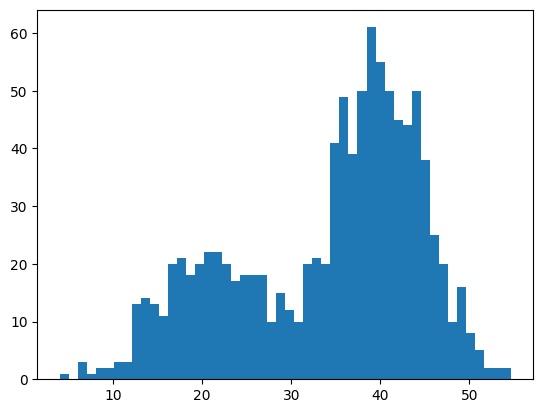

In [34]:
plt.hist(sample,bins=50)

In [35]:
from sklearn.neighbors import KernelDensity

model = KernelDensity(bandwidth=2, kernel='gaussian')

# covert data into 2D array because it accept 2D array values
sample = sample.reshape((len(sample), 1))
model.fit(sample) # it meant model calculate the result 5 kernel 

,"bandwidth bandwidth: float or {""scott"", ""silverman""}, default=1.0The bandwidth of the kernel. If bandwidth is a float, it defines thebandwidth of the kernel. If bandwidth is a string, one of the estimationmethods is implemented.",2
,"algorithm algorithm: {'kd_tree', 'ball_tree', 'auto'}, default='auto'The tree algorithm to use.",'auto'
,"kernel kernel: {'gaussian', 'tophat', 'epanechnikov', 'exponential', 'linear', 'cosine'}, default='gaussian'The kernel to use.",'gaussian'
,"metric metric: str, default='euclidean'Metric to use for distance computation. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.Not all metrics are valid with all algorithms: refer to thedocumentation of :class:`BallTree` and :class:`KDTree`. Note that thenormalization of the density output is correct only for the Euclideandistance metric.",'euclidean'
,"atol atol: float, default=0The desired absolute tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"rtol rtol: float, default=0The desired relative tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"breadth_first breadth_first: bool, default=TrueIf true (default), use a breadth-first approach to the problem.Otherwise use a depth-first approach.",True
,"leaf_size leaf_size: int, default=40Specify the leaf size of the underlying tree. See :class:`BallTree`or :class:`KDTree` for details.",40
,"metric_params metric_params: dict, default=NoneAdditional parameters to be passed to the tree for use with themetric. For more information, see the documentation of:class:`BallTree` or :class:`KDTree`.",None
Name,Type,Value
"bandwidth_ bandwidth_: floatValue of the bandwidth, given directly by the bandwidth parameter orestimated using the 'scott' or 'silverman' method... versionadded:: 1.0",int,2


In [36]:
values = np.linspace(sample.min(),sample.max(),100) # Generate random value between min() and max() with the size of 100
values = values.reshape((len(values), 1)) # covert the values into 2D array

In [37]:
probabilities = model.score_samples(values)
probabilities = np.exp(probabilities) # covert into normal number from log result to exponent

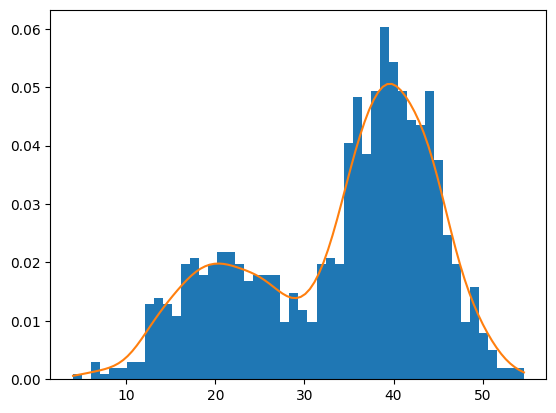

In [38]:
plt.hist(sample, bins=50, density=True)
plt.plot(values[:], probabilities)
plt.show()

<Axes: ylabel='Density'>

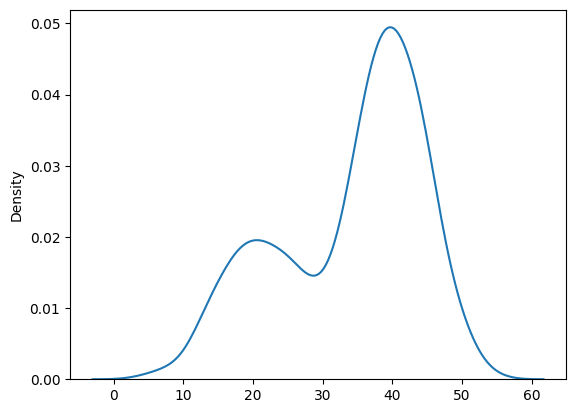

In [ ]:
import seaborn as sns # This is Done in short way using seaborn class called kdeplot but this accept 1D array not 2D
sns.kdeplot(sample.reshape(1000), bw_adjust=0.9)